<a href="https://colab.research.google.com/github/athifashihab/FDS-InclassActivity-Group06/blob/main/Group_6_Gapminder_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group No: 6
## Members:
- ATHIFA SHARIN SHIHAB ERAMANGALATH(U24200842)
- AISHA JALIL IBRAHIM AL DAHHAN(U25103468)
- KHULOOD ISMAIL HAJ ABED GHAZAL(U25200155)

**In-Class Team-Based Learning Activity** : Exploring Global Health & Wealth with Gapminder Data **[15 MARKS]**

---

## Objective

In this activity you will work in teams to explore **global health and economic data**.

You will work with **two separate Gapminder CSV datasets** that share a common key (`country`) and must be **joined (merged by column)** to answer meaningful questions about the relationship between wealth, health, and population.

### Datasets

Download the datasets from the Blackboard:

| File | Description |
|------|-------------|
| `Gapminder_Health.csv` | Country, Year, Continent, Life expectancy, Population |
| `gapminder_economy.csv` | Country, Year, GDP per capita |

> **Note :** Both datasets contain one row per (country, year) pair. They share `country` and `year` columns but carry **different** variables — you must **join them on `country`** to get a combined view.

### Key Columns After Joining

| Column | Dataset | Description |
|--------|---------|-------------|
| `country` | both (join key) | Country name |
| `continent` | health | Geographic region |
| `year` | both | 5-year interval (1952–2007) |
| `lifeExp` | health | Life expectancy at birth (years) |
| `pop` | health | Population |
| `gdpPercap` | economy | GDP per capita (USD, inflation-adjusted) |

### You will:
1. Load and **join (merge by columns)** the two datasets on `country`
2. **Explore** the joined data using Table methods
3. **Visualise** patterns with Table-based plots
4. **Define and use functions** with `.apply()`



## Setup – Install & Import

In [2]:
!pip install datascience

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.1/725.1 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.0 MB/s eta 0:00:00


In [3]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
print('Libraries loaded successfully!')

Libraries loaded successfully!


---

## Task 1 — Load and Join the Datasets **[2 marks]**

**Goal :** Load each CSV file into its own `Table`, then use `.join()` to merge them by the shared key `country`.

The `datascience` library's `.join()` works like a database inner join:

```python
merged = table_A.join('shared_column', table_B)
```

### Step 1.1 – Download and load the health dataset

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Gapminder_Economy.csv to Gapminder_Economy.csv
Saving Gapminder_Health.csv to Gapminder_Health.csv


In [5]:
# Load the Gapminder Health dataset and assign it to 'health' table variable
health = Table.read_table('Gapminder_Health.csv')
# Show the first 5 records
health.show(5)
# Show the number of columns and number of rows
print('Number of columns:', health.num_columns)
print('Number of rows:', health.num_rows)

country,year,continent,lifeExp,pop
Afghanistan,1952,Asia,28.801,8.42533e+06
Afghanistan,1957,Asia,30.332,9.24093e+06
Afghanistan,1962,Asia,31.997,1.02671e+07
Afghanistan,1967,Asia,34.02,1.1538e+07
Afghanistan,1972,Asia,36.088,1.30795e+07


Number of columns: 5
Number of rows: 1704


### Step 1.2 – Load the economy dataset

In [6]:
# Load the Gapminder Economy dataset and assign it to 'economy' table variable
economy = Table.read_table('Gapminder_Economy.csv')
# Show the first 5 records
economy.show(5)
# Show the number of columns and number of rows
print('Number of columns:', economy.num_columns)
print('Number of rows:', economy.num_rows)


country,year,gdpPercap
Afghanistan,1952,779.445
Afghanistan,1957,820.853
Afghanistan,1962,853.101
Afghanistan,1967,836.197
Afghanistan,1972,739.981


Number of columns: 3
Number of rows: 1632


### Step 1.3 – Filter both tables to the **same year** before joining

Because each country appears multiple times (once per year), first filter to a single year so each country appears exactly once — making the join unambiguous.

> Use **year 2007** (the most recent in the dataset).


In [7]:
# Keep only 2007 records in two datasets and assign them to new Tables
health_2007 = health.where('year', are.equal_to(2007))
economy_2007 = economy.where('year', are.equal_to(2007))
# Display how many countries there are in two new tables: health_2007 and economy_2007
print('Countries in health_2007:', health_2007.num_rows)
print('Countries in economy_2007:', economy_2007.num_rows)

Countries in health_2007: 142
Countries in economy_2007: 136


### Step 1.4 – Join the two tables on `country`

In [8]:
# Join health data with economy data on 'country'
# health_2007 has: country, continent, year, lifeExp, pop
# economy_2007 has: country, year, gdpPercap

world = health_2007.join('country', economy_2007)
world.show(5)
print('Number of rows:', world.num_rows)
print('Number of columns:', world.num_columns)


country,year,continent,lifeExp,pop,year_2,gdpPercap
Afghanistan,2007,Asia,43.828,3.18899e+07,2007,974.58
Albania,2007,Europe,76.423,3.60052e+06,2007,5937.03
Algeria,2007,Africa,72.301,3.33332e+07,2007,6223.37
Angola,2007,Africa,42.731,1.24205e+07,2007,4797.23
Argentina,2007,Americas,75.32,4.03019e+07,2007,12779.4


Number of rows: 136
Number of columns: 7


**✏️ Question 1.1 :** How many columns does the joined table have? Explain the columns in the joined table.









The joined table has **7 columns** and **136 rows**. The columns are:

- `country`: country name used as the join key  
- `continent`: continent from the health dataset  
- `year`: year from the health dataset  
- `lifeExp`: life expectancy  
- `pop`: population  
- `year_2` / second year column: year from the economy dataset  
- `gdpPercap`: GDP per capita  

The row count is 136 because the join is an inner join, so only countries present in both 2007 datasets are kept. It combines health indicators with economic indicators for each country in 2007.




**✏️ Question 1.2 :** What would happen if we joined without filtering to a single year first? Why?

If we joined without filtering to a single year first, the result would be a **many-to-many join**. Each country would appear multiple times in both datasets. Joining only on country would create repeated combinations of years for each country, producing incorrect duplicate rows.Each country appears 12 times in both datasets (one row per year from 1952–2007). Joining without filtering would pair every health row for a country with every economy row for the same country — producing **144 rows per country** instead of 1, and mixing values from different years incorrectly (e.g., 1952 life expectancy paired with 2007 GDP). Filtering to year 2007 first ensures each country appears exactly once, making the join clean and unambiguous.

---

## Task 2 — Explore the Joined Data Using Tables **[3 marks]**

**Goal :** Use `.select()`, `.where()`, `.group()`, and `.sort()` to extract insights.

### Step 2.1 – Select relevant columns


In [11]:
# Keep the columns in world we care about and give them clean names
# They are 'country', 'continent', 'lifeExp', 'pop', 'gdpPercap'
world = world.select('country', 'continent', 'lifeExp', 'pop', 'gdpPercap')
# show the first 5 records
world.show(5)


country,continent,lifeExp,pop,gdpPercap
Afghanistan,Asia,43.828,3.18899e+07,974.58
Albania,Europe,76.423,3.60052e+06,5937.03
Algeria,Africa,72.301,3.33332e+07,6223.37
Angola,Africa,42.731,1.24205e+07,4797.23
Argentina,Americas,75.32,4.03019e+07,12779.4


### Step 2.2 – Filter rows

In [12]:
# Create a new table, high_life, containing the countries with life expectancy above 80 years
high_life = world.where('lifeExp', are.above(80))
# Display them
high_life.show()


country,continent,lifeExp,pop,gdpPercap
Australia,Oceania,81.235,2.04342e+07,34435.4
Canada,Americas,80.653,3.33901e+07,36319.2
France,Europe,80.657,6.10839e+07,30470
Iceland,Europe,81.757,301931,36180.8
Israel,Asia,80.745,6.42668e+06,25523.3
Italy,Europe,80.546,5.81477e+07,28569.7
Japan,Asia,82.603,1.27468e+08,31656.1
New Zealand,Oceania,80.204,4.11577e+06,25185
Norway,Europe,80.196,4.62793e+06,49357.2
Spain,Europe,80.941,4.04482e+07,28821.1


In [13]:
# Create a new table, asia, containing the countries in Asia only
asia = world.where('continent', are.equal_to('Asia'))
# Display how many countries in Asia
print('Number of countries in Asia:', asia.num_rows)
# Sort the countries in alphabetic order and show the first 10 of them
asia.sort('country').show(10)


Number of countries in Asia: 29


country,continent,lifeExp,pop,gdpPercap
Afghanistan,Asia,43.828,3.18899e+07,974.58
Bahrain,Asia,75.635,708573,29796
Bangladesh,Asia,64.062,1.50448e+08,1391.25
Cambodia,Asia,59.723,1.41319e+07,1713.78
China,Asia,72.961,1.31868e+09,4959.11
India,Asia,64.698,1.1104e+09,2452.21
Indonesia,Asia,70.65,2.23547e+08,3540.65
Iran,Asia,70.964,6.94536e+07,11605.7
Iraq,Asia,59.545,2.74996e+07,4471.06
Israel,Asia,80.745,6.42668e+06,25523.3


### Step 2.3 – Summarise data

In [16]:
# Calculate the Average life expectancy per continent
avg_life = world.select('continent', 'lifeExp').group('continent', np.mean).relabeled('lifeExp mean', 'Average Life Expectancy')

# and show them in descending order.
avg_life.sort('Average Life Expectancy', descending=True).show()


continent,Average Life Expectancy
Oceania,80.7195
Europe,77.6486
Americas,73.6081
Asia,70.4557
Africa,54.9626


In [19]:
# Calculate the Average GDP per capita per continent
avg_gdp = world.select('continent', 'gdpPercap').group('continent', np.mean).relabeled('gdpPercap mean', 'Average GDP per Capita')
# and display them in ascending order
avg_gdp.sort('Average GDP per Capita', descending=False).show()


continent,Average GDP per Capita
Africa,3134.39
Americas,11003
Asia,11884.9
Europe,25054.5
Oceania,29810.2


**✏️ Question 2.1 :** Which continent has the highest average life expectancy in 2007? Which has the lowest?




Based on the 2007 data:

- **Highest average life expectancy:** **Oceania** (80.72 years), followed by Europe (~77.65 years).
- **Lowest average life expectancy:** **Africa** (54.96 years).

Africa's significantly lower life expectancy reflects the impact of HIV/AIDS, poverty, and limited healthcare access in sub-Saharan Africa.

**✏️ Question 2.2 :** Write code to find the **top 5 countries by GDP per capita** in the dataset. Are any of them surprising?



In [20]:
# Your code for Question 2.2 here

top5_gdp = world.sort('gdpPercap', descending=True).select('country', 'continent', 'gdpPercap')
top5_gdp.show(5)


country,continent,gdpPercap
Norway,Europe,49357.2
Kuwait,Asia,47307
Singapore,Asia,47143.2
United States,Americas,42951.7
Ireland,Europe,40676


The top 5 countries by GDP per capita in 2007 are:

1.   **Norway** (Europe) — $49,357

2.   **Kuwait** (Asia) — $47,307

3. **Singapore** (Asia) — $47,143

4. **United States** (Americas) — $42,952

5. **Ireland** (Europe) — $40,676

Kuwait and Singapore may be surprising — Kuwait due to its oil wealth, and Singapore as a small city-state with a highly developed trade economy.

---

## Task 3 — Visualise the Data Using Table-Based Plots **[5 marks]**

**Goal :** Use `.barh()`, `.hist()`, and `.scatter()` to reveal patterns.

### Step 3.1 – Bar chart: average life expectancy by continent


Text(0, 0.5, 'Continent')

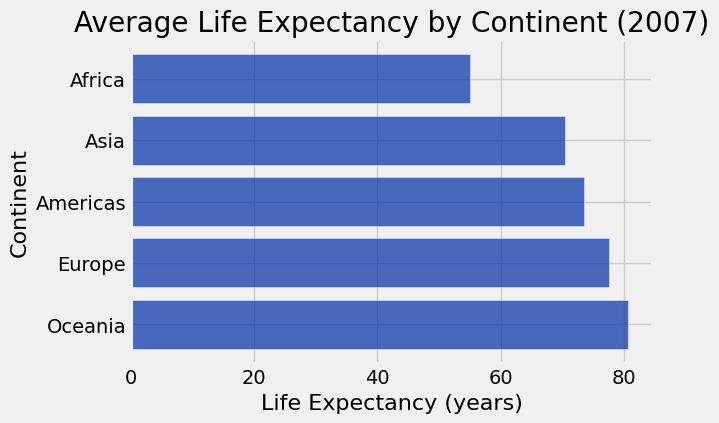

In [22]:
# Show the Average Life Expectancy by Continent (2007) using barh graphic

avg_life_bar = world.select('continent', 'lifeExp').group('continent', np.mean).relabeled('lifeExp mean','Average Life Expectancy')
avg_life_bar.sort('Average Life Expectancy').barh('continent', 'Average Life Expectancy')
plots.title('Average Life Expectancy by Continent (2007)')
plots.xlabel('Life Expectancy (years)')
plots.ylabel('Continent')


### Step 3.2 – Histogram: distribution of GDP per capita

Text(0.5, 0, 'GDP per Capita (USD)')

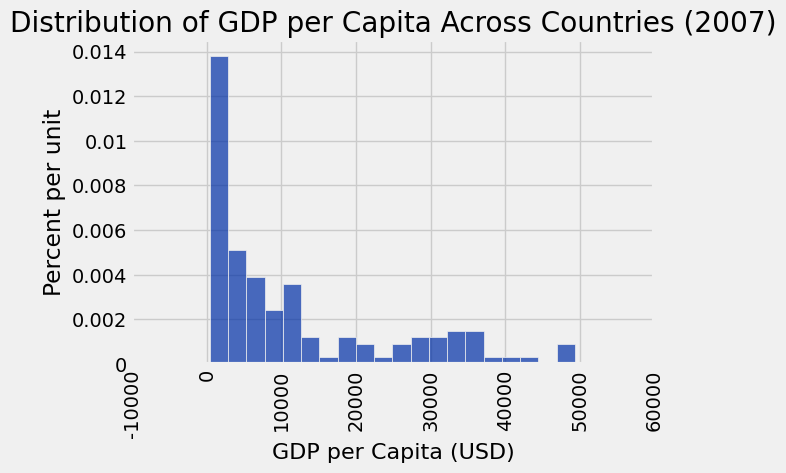

In [23]:
# Show the Distribution of GDP per Capita Across Countries (2007) using a histogram with 20 bins

world.hist('gdpPercap', bins=20)
plots.title('Distribution of GDP per Capita Across Countries (2007)')
plots.xlabel('GDP per Capita (USD)')


### Step 3.3 – Scatter plot: GDP per capita vs. life expectancy

Text(0, 0.5, 'Life Expectancy (years)')

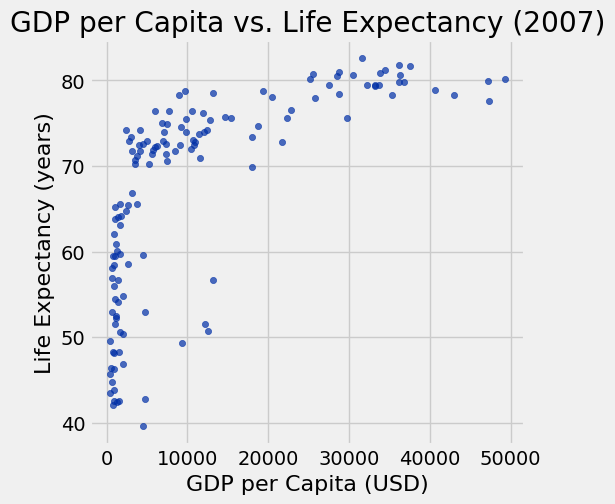

In [ ]:
# Show GDP per Capita vs. Life Expectancy (2007) using a Scatter plot.

world.scatter('gdpPercap', 'lifeExp')
plots.title('GDP per Capita vs. Life Expectancy (2007)')
plots.xlabel('GDP per Capita (USD)')
plots.ylabel('Life Expectancy (years)')


**✏️ Question 3.1 :** Describe the relationship between GDP per capita and life expectancy. Is it linear or non-linear? What does this suggest?







The relationship between GDP per capita and life expectancy is **non-linear (logarithmic)**. At low GDP levels (below 10,000), increases in income are associated with large gains in life expectancy. At higher GDP levels (above $20,000), the gains flatten out — each additional dollar of GDP brings smaller improvements in life expectancy. This suggests that basic wealth (access to food, clean water, healthcare) has the greatest impact on health in poorer countries, while beyond a certain threshold, additional wealth provides diminishing returns.

**✏️ Question 3.2 (Challenge) :** Create a bar chart showing the **5 countries with the lowest life expectancy**. What continent are most of them on?


country,continent,lifeExp
Swaziland,Africa,39.613
Mozambique,Africa,42.082
Zambia,Africa,42.384
Sierra Leone,Africa,42.568
Lesotho,Africa,42.592


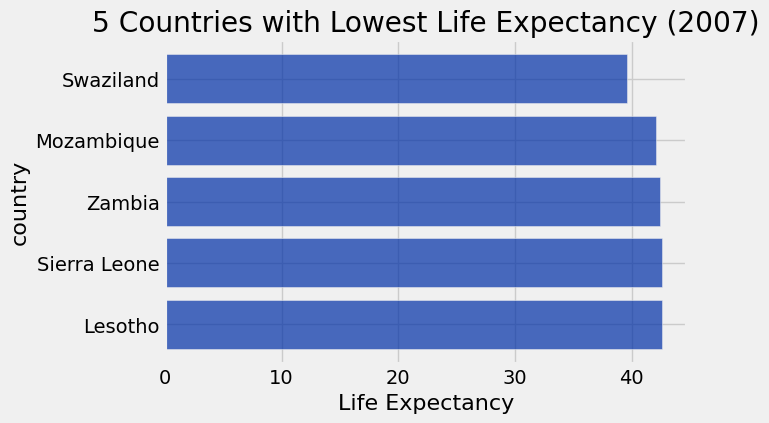

In [25]:
# Your code for Question 3.2 here

bottom5 = world.sort('lifeExp').select('country', 'continent', 'lifeExp').take(np.arange(5))
bottom5.barh('country', 'lifeExp')
plots.title('5 Countries with Lowest Life Expectancy (2007)')
plots.xlabel('Life Expectancy')
bottom5.show()


The 5 countries with the lowest life expectancy in 2007 are:

1. **Swaziland** (Africa) — 39.6 years
2. **Mozambique** (Africa) — 42.1 years
3. **Zambia** (Africa) — 42.4 years
4. **Sierra Leone** (Africa) — 42.6 years
5. **Lesotho** (Africa) — 42.6 years

All 5 are in **Africa**. This indicates that, in 2007, the lowest life expectancy values in the joined dataset were concentrated in African countries.The primary driver in southern African countries like Swaziland, Zambia, and Lesotho is the severe HIV/AIDS epidemic, combined with poverty and limited healthcare.

---

## Task 4 — Define and Use Functions with Tables **[5 marks]**

**Goal :** Write Python functions and apply them to table columns.

### Step 4.1 – Classify countries by income level

The World Bank uses GDP per capita thresholds to classify countries. The following defines a simplified version
and will be used to develop the function:

| Category | GDP per capita (USD) |  String to be returned |
|----------|----------------------|------------------------|
| Low income | < 1 000 |          'Low income'           |
| Lower-middle income | 1 000 – 3 999 | 'Lower-middle income'   |
| Upper-middle income | 4 000 – 12 999 | 'Upper-middle income' |
| High income | ≥ 13 000 | 'High income' |


In [26]:
# Implement income_group function
# It returns a World-Bank-style income classification based on GDP per capita.


#Your code here
def income_group(gdp):
    if gdp < 1000:
        return 'Low income'
    elif gdp < 4000:
        return 'Lower-middle income'
    elif gdp < 13000:
        return 'Upper-middle income'
    else:
        return 'High income'


# Quick test for your function
print(income_group(500))    # Low income
print(income_group(2500))   # Lower-middle income
print(income_group(8000))   # Upper-middle income
print(income_group(40000))  # High income


Low income
Lower-middle income
Upper-middle income
High income


In [27]:
# Apply the function to the gdpPercap column
world_with_income = world.with_column('income_group', world.apply(income_group, 'gdpPercap'))
# Display the first 5 records
world_with_income.show(5)


country,continent,lifeExp,pop,gdpPercap,income_group
Afghanistan,Asia,43.828,3.18899e+07,974.58,Low income
Albania,Europe,76.423,3.60052e+06,5937.03,Upper-middle income
Algeria,Africa,72.301,3.33332e+07,6223.37,Upper-middle income
Angola,Africa,42.731,1.24205e+07,4797.23,Upper-middle income
Argentina,Americas,75.32,4.03019e+07,12779.4,Upper-middle income


In [28]:
# How many countries in each income group?
# Use an appropriate function to answer this question

world_with_income.group('income_group').sort('count', descending=True)


income_group,count
Upper-middle income,43
High income,39
Lower-middle income,35
Low income,19


---

## Grading Distribution (Out of 25)

| Task | Description | Marks |
|------|-------------|-------|
| 1 | Load and join datasets with `.join()` | 2 |
| 2 | Explore with `.select()`, `.where()`, `.group()` | 3 |
| 3 | Visualise with `.barh()`, `.hist()`, `.scatter()` | 5 |
| 4 | Functions & `.apply()` | 5 |
| **Total** | | **15** |


## Submission Instructions

- **1. File Requirements**
  - **File Name :** Save your notebook as `Group_No_Gapminder_Analysis.ipynb`. Replace `Group_No` with your assigned group number.
  - **Self-Contained :** Run all cells before submitting. Include all outputs and Markdown explanations.
  - **Colab Compatibility :** Test that the notebook opens and runs via "Open in Colab":

    [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your_username/your_repo/blob/main/Group_No_Gapminder_Analysis.ipynb)

    Replace `your_username`, `your_repo`, and `Group_No` with your actual Github username, repository name, and group no, accordingly.

- **2. Group Information**
  Include the group number and all member names at the bottom of this text block.

- **3. Submission Process**
  - **GitHub :** Upload the completed notebook to a public repository with a `README.md`.
  - **Blackboard :** Submit the GitHub link **and** upload the `.ipynb` file as backup.


# Group No:06
## Members:
- ATHIFA SHARIN SHIHAB ERAMANGALATH(U24200842)
- AISHA JALIL IBRAHIM AL DAHHAN(U25103468)
- KHULOOD ISMAIL HAJ ABED GHAZAL(U25200155)
